- Importing Required Libraries

In [1]:
# Data handling
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt

# Machine learning tools
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

- Loading the Dataset

In [2]:
# Load Iris dataset
iris = load_iris()

X = iris.data
y = iris.target

# Convert to DataFrame for easier inspection
df = pd.DataFrame(X, columns=iris.feature_names)
df['target'] = y

print(df.head())

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   target  
0       0  
1       0  
2       0  
3       0  
4       0  


- Exploring the Dataset

In [3]:
print("Dataset Shape:", df.shape)

print("\nFeature Names:")
print(iris.feature_names)

print("\nTarget Classes:")
print(iris.target_names)

print("\nClass Distribution:")
print(df['target'].value_counts())

Dataset Shape: (150, 5)

Feature Names:
['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']

Target Classes:
['setosa' 'versicolor' 'virginica']

Class Distribution:
target
0    50
1    50
2    50
Name: count, dtype: int64


- Visualizing the Dataset

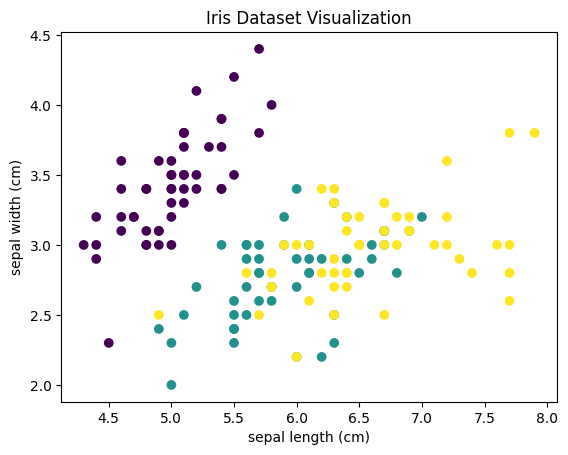

In [4]:
plt.scatter(X[:,0], X[:,1], c=y)
plt.xlabel(iris.feature_names[0])
plt.ylabel(iris.feature_names[1])
plt.title("Iris Dataset Visualization")
plt.show()

- This helps us understand how KNN will separate the classes.

- Split Dataset into Training and Testing Sets

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Training samples:", X_train.shape)
print("Testing samples:", X_test.shape)

Training samples: (120, 4)
Testing samples: (30, 4)


- Training the KNN Model

In [6]:
knn = KNeighborsClassifier(
    n_neighbors=3,
    metric="euclidean"
)

knn.fit(X_train, y_train)

KNeighborsClassifier(metric='euclidean', n_neighbors=3)

- Making Predictions

In [7]:
y_pred = knn.predict(X_test)

print("Predictions:")
print(y_pred[:10])

Predictions:
[1 0 2 1 1 0 1 2 1 1]


- Evaluating Model Performance

In [8]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 1.0

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30


Confusion Matrix:
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


- Inspecting the Nearest Neighbors

In [9]:
sample = X_test[0].reshape(1,-1)

distances, indices = knn.kneighbors(sample)

print("Nearest Neighbor Indices:", indices)
print("Distances:", distances)

Nearest Neighbor Indices: [[79 90 39]]
Distances: [[0.2236068  0.3        0.43588989]]


- Finding the Best Value of K

In [10]:
k_values = range(1,21)
accuracies = []

for k in k_values:
    
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train, y_train)
    
    predictions = model.predict(X_test)
    
    acc = accuracy_score(y_test, predictions)
    accuracies.append(acc)

- Plotting Accuracy vs K

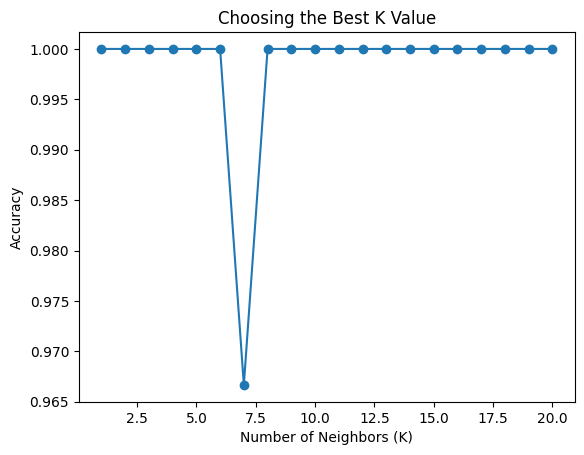

In [11]:
plt.plot(k_values, accuracies, marker='o')
plt.xlabel("Number of Neighbors (K)")
plt.ylabel("Accuracy")
plt.title("Choosing the Best K Value")
plt.show()

- Training the  Final Model with Best K

In [12]:
best_k = k_values[np.argmax(accuracies)]

print("Best K:", best_k)

final_model = KNeighborsClassifier(n_neighbors=best_k)
final_model.fit(X_train, y_train)

final_predictions = final_model.predict(X_test)

print("Final Accuracy:", accuracy_score(y_test, final_predictions))

Best K: 1
Final Accuracy: 1.0
